In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Read the Excel file

df = pd.read_excel(r"C:\Users\goudm\Downloads\Dataset for Data Analytics.xlsx")

# Display first 5 rows

df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [5]:
# Check the number of rows and columns

df.shape

(1200, 14)

In [8]:
# Display column names

df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')

In [9]:
# Check data types

df.dtypes

OrderID                    object
Date               datetime64[ns]
CustomerID                 object
Product                    object
Quantity                    int64
UnitPrice                 float64
ShippingAddress            object
PaymentMethod              object
OrderStatus                object
TrackingNumber             object
ItemsInCart                 int64
CouponCode                 object
ReferralSource             object
TotalPrice                float64
dtype: object

In [10]:
# Get basic information about the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

In [ ]:
# Check missing values in each column

df.isnull().sum()

In [11]:
# Show columns with missing values

missing_values = df.isnull().sum()

print(missing_values[missing_values > 0])

CouponCode    309
dtype: int64


In [12]:
# Replace missing coupon codes

df["CouponCode"] = df["CouponCode"].fillna("No Coupon")

# Check again

df["CouponCode"].isnull().sum()

np.int64(0)

In [13]:
# Count duplicate rows

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [14]:
# Select numerical columns

numeric_columns = ["Quantity", "UnitPrice", "ItemsInCart", "TotalPrice"]

# Calculate basic statistics

df[numeric_columns].describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


In [15]:
# Calculate count, mean and median

statistics = pd.DataFrame({
    "Count": df[numeric_columns].count(),
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median()
})

statistics

,Count,Mean,Median
Quantity,1200,2.945833,3.000
UnitPrice,1200,356.412750,364.210
ItemsInCart,1200,5.485000,5.000
TotalPrice,1200,1053.968300,823.615


In [16]:
# Calculate total sales

total_sales = df["TotalPrice"].sum()

print("Total Sales:", total_sales)

Total Sales: 1264761.96


In [17]:
# Calculate average order value

average_order_value = df["TotalPrice"].mean()

print("Average Order Value:", average_order_value)

Average Order Value: 1053.9683


In [18]:
# Find minimum and maximum order value

print("Minimum Order Value:", df["TotalPrice"].min())
print("Maximum Order Value:", df["TotalPrice"].max())

Minimum Order Value: 11.39
Maximum Order Value: 3456.4


In [19]:
# Count orders for each product

product_orders = df["Product"].value_counts()

print(product_orders)

Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64


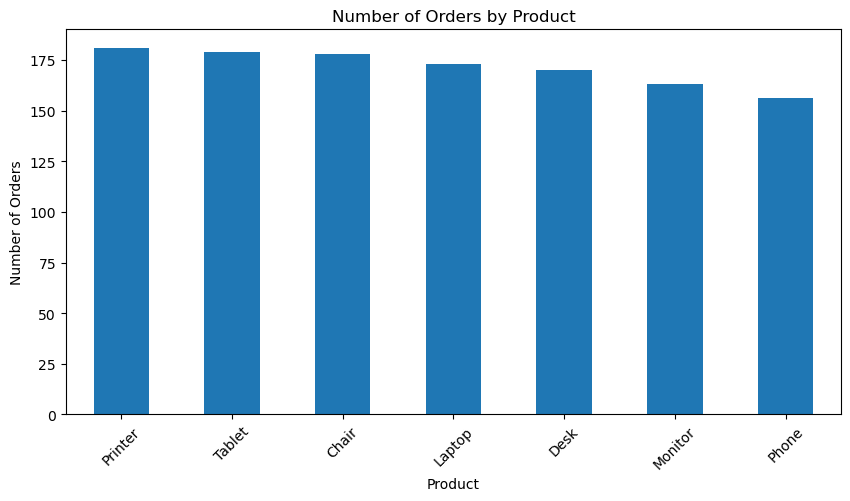

In [20]:
# Create a bar chart to analyze products

product_orders.plot(kind="bar", figsize=(10, 5))

plt.title("Number of Orders by Product")
plt.xlabel("Product")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.show()

In [21]:
# Calculate total sales for each product

product_sales = df.groupby("Product")["TotalPrice"].sum().sort_values(ascending=False)

print(product_sales)

Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Desk       167459.93
Phone      151722.39
Name: TotalPrice, dtype: float64


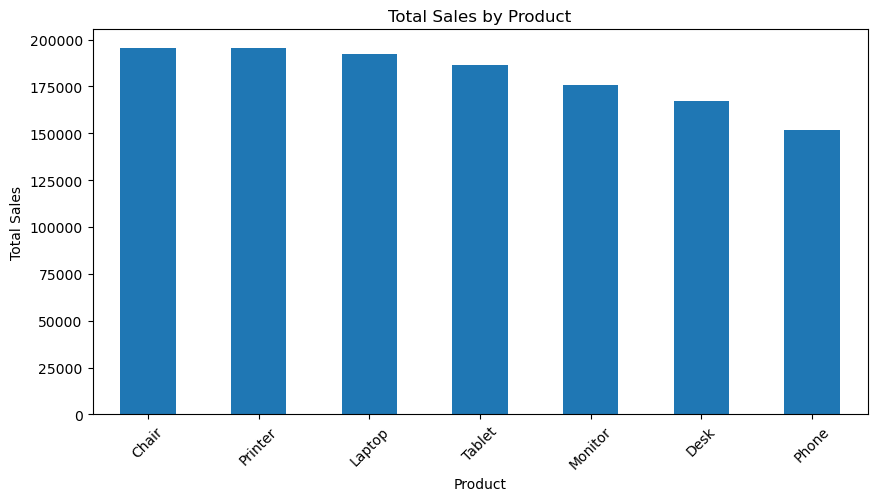

In [22]:
# Plot product sales

product_sales.plot(kind="bar", figsize=(10, 5))

plt.title("Total Sales by Product")
plt.xlabel("Product")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()

In [23]:
# Count orders by order status

order_status = df["OrderStatus"].value_counts()

print(order_status)

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64


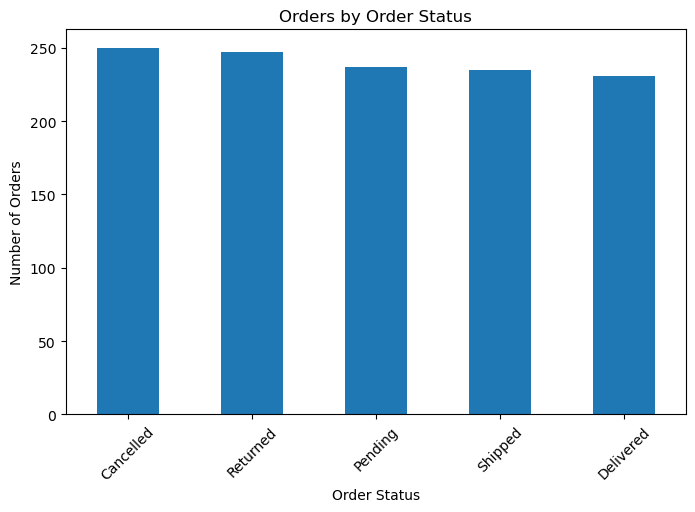

In [24]:
# Create a bar chart for analyzing order status

order_status.plot(kind="bar", figsize=(8, 5))

plt.title("Orders by Order Status")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.show()

In [25]:
# Count orders by payment method

payment_methods = df["PaymentMethod"].value_counts()

print(payment_methods)

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64


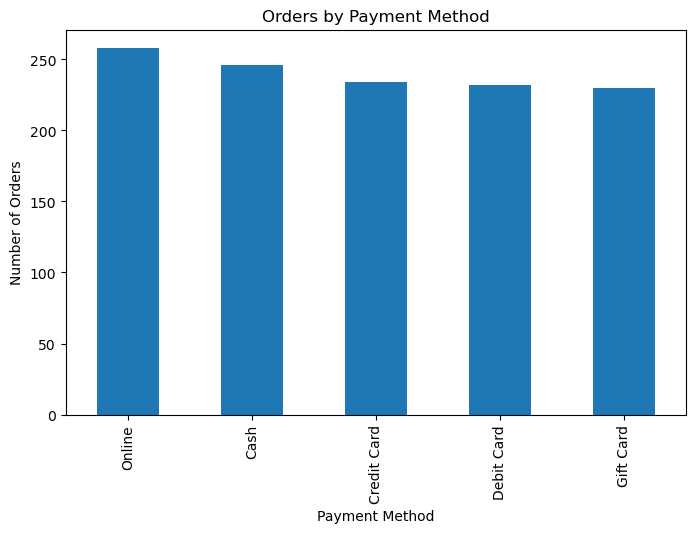

In [26]:
# Plot payment methods

payment_methods.plot(kind="bar", figsize=(8, 5))

plt.title("Orders by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")

plt.show()

In [27]:
# Count customers/orders by referral source

referral_sources = df["ReferralSource"].value_counts()

print(referral_sources)

ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64


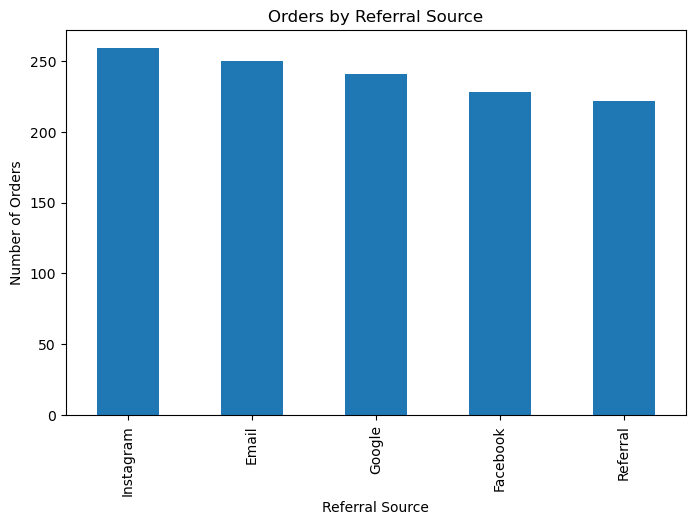

In [28]:
# Plot referral sources

referral_sources.plot(kind="bar", figsize=(8, 5))

plt.title("Orders by Referral Source")
plt.xlabel("Referral Source")
plt.ylabel("Number of Orders")

plt.show()

In [29]:
# Count coupon usage

coupon_usage = df["CouponCode"].value_counts()

print(coupon_usage)

CouponCode
FREESHIP     313
No Coupon    309
WINTER15     292
SAVE10       286
Name: count, dtype: int64


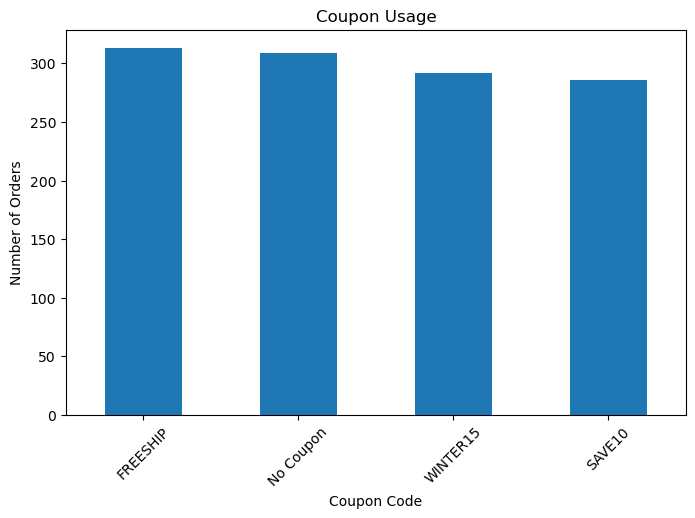

In [30]:
# Plot coupon usage

coupon_usage.plot(kind="bar", figsize=(8, 5))

plt.title("Coupon Usage")
plt.xlabel("Coupon Code")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.show()

In [34]:
# Extract month from Date

df["Month"] = df["Date"].dt.month

In [35]:
# Calculate total sales for each month

monthly_sales = df.groupby("Month")["TotalPrice"].sum()

print(monthly_sales)

Month
1     124313.23
2     112344.78
3     123840.93
4     109186.05
5     135142.59
6     170616.13
7      85784.64
8      86343.21
9      69321.65
10     89834.82
11     75493.43
12     82540.50
Name: TotalPrice, dtype: float64


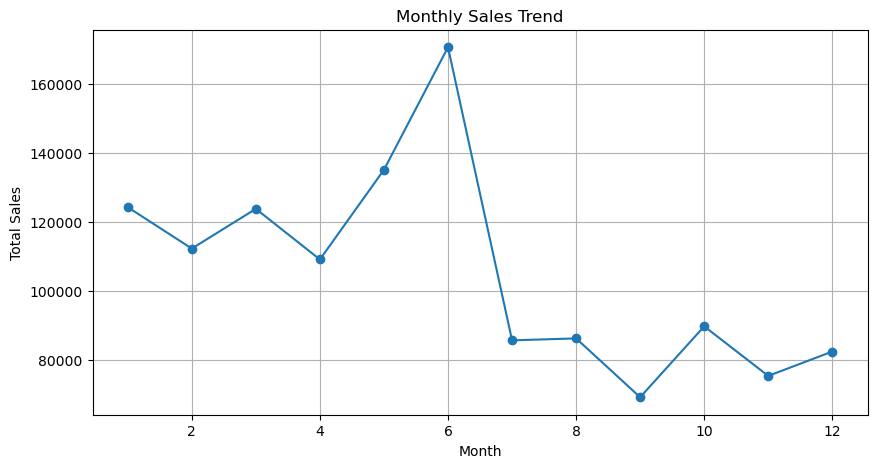

In [36]:
# Plot monthly sales trend

monthly_sales.plot(kind="line", marker="o", figsize=(10, 5))

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.grid(True)

plt.show()

In [37]:
# Extract year from Date

df["Year"] = df["Date"].dt.year

# Calculate yearly sales

yearly_sales = df.groupby("Year")["TotalPrice"].sum()

print(yearly_sales)

Year
2023    552643.24
2024    480235.87
2025    231882.85
Name: TotalPrice, dtype: float64


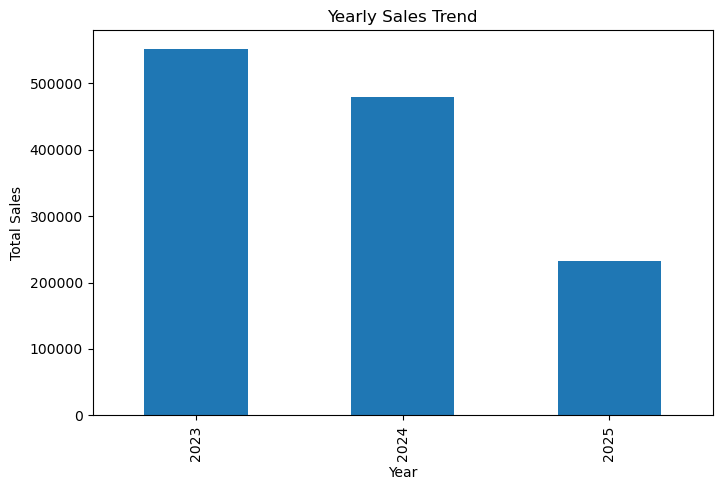

In [38]:
# Plot yearly sales trend

yearly_sales.plot(kind="bar", figsize=(8, 5))

plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Total Sales")

plt.show()

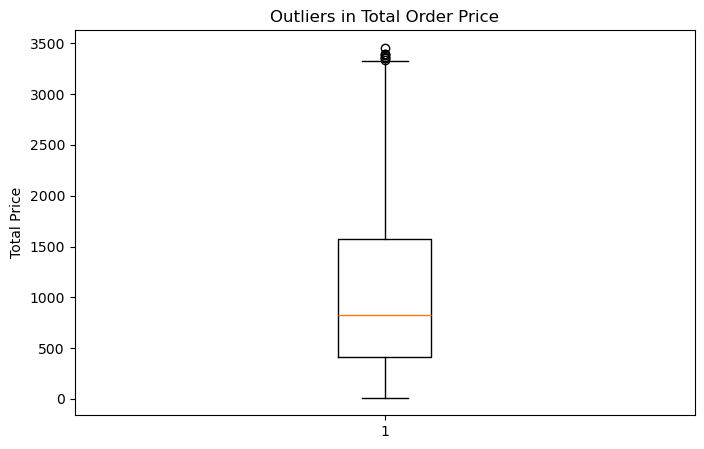

In [39]:
# Create box plot for TotalPrice

plt.figure(figsize=(8, 5))

plt.boxplot(df["TotalPrice"])

plt.title("Outliers in Total Order Price")
plt.ylabel("Total Price")

plt.show()

In [40]:
# Calculate Q1 and Q3 usind IQR method for identifying outliers

Q1 = df["TotalPrice"].quantile(0.25)
Q3 = df["TotalPrice"].quantile(0.75)

# Calculate IQR

IQR = Q3 - Q1

# Calculate lower and upper limits

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Lower Limit: -1341.4125
Upper Limit: 3330.4075


In [41]:
# Find outlier records

outliers = df[
    (df["TotalPrice"] < lower_limit) |
    (df["TotalPrice"] > upper_limit)
]

print("Number of outliers:", len(outliers))

outliers.head()

Number of outliers: 8


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Month,Year
107,ORD200107,2023-03-27,C16775,Printer,5,670.75,848 Main St,Gift Card,Shipped,TRK34392124,8,FREESHIP,Instagram,3353.75,3,2023
326,ORD200326,2024-07-01,C65986,Laptop,5,670.48,273 Main St,Gift Card,Returned,TRK98353867,5,SAVE10,Facebook,3352.40,7,2024
328,ORD200328,2023-02-28,C18404,Tablet,5,674.04,546 Main St,Online,Cancelled,TRK89401624,7,SAVE10,Google,3370.20,2,2023
469,ORD200469,2023-11-26,C13877,Chair,5,676.98,893 Main St,Cash,Cancelled,TRK17254691,5,No Coupon,Facebook,3384.90,11,2023
632,ORD200632,2023-05-02,C67260,Laptop,5,678.16,463 Main St,Gift Card,Delivered,TRK38229104,7,WINTER15,Facebook,3390.80,5,2023


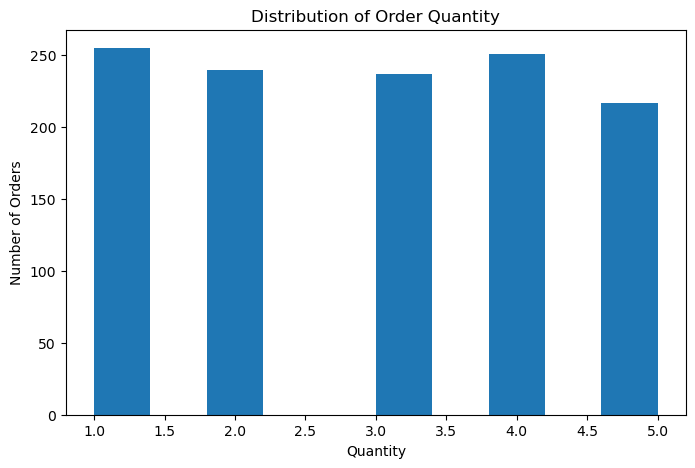

In [42]:
# Create histogram for analyzing Quantity distribution

plt.figure(figsize=(8, 5))

plt.hist(df["Quantity"], bins=10)

plt.title("Distribution of Order Quantity")
plt.xlabel("Quantity")
plt.ylabel("Number of Orders")

plt.show()

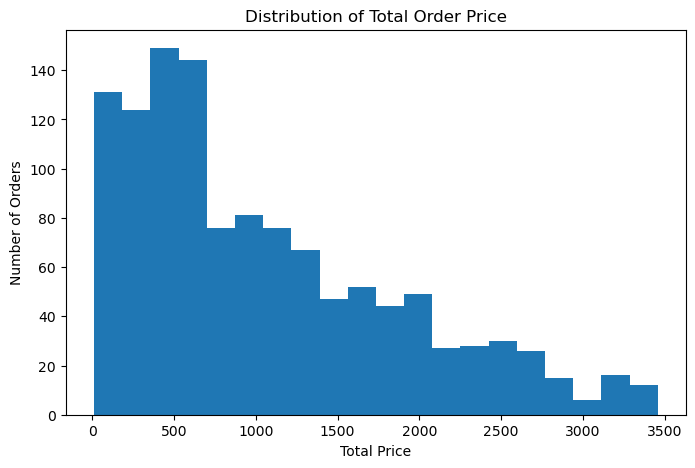

In [43]:
# Create histogram for analayzing TotalPrice distribution

plt.figure(figsize=(8, 5))

plt.hist(df["TotalPrice"], bins=20)

plt.title("Distribution of Total Order Price")
plt.xlabel("Total Price")
plt.ylabel("Number of Orders")

plt.show()

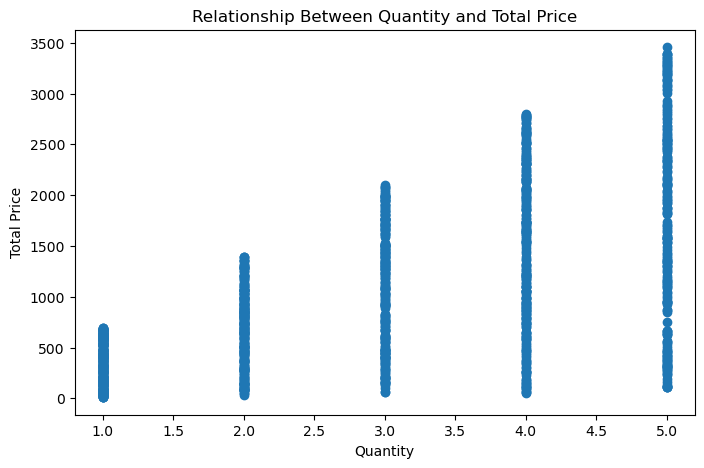

In [44]:
# Create scatter plot

plt.figure(figsize=(8, 5))

plt.scatter(df["Quantity"], df["TotalPrice"])

plt.title("Relationship Between Quantity and Total Price")
plt.xlabel("Quantity")
plt.ylabel("Total Price")

plt.show()

In [45]:
# Select numerical columns

numeric_data = df[["Quantity", "UnitPrice", "ItemsInCart", "TotalPrice"]]

# Calculate correlation

correlation = numeric_data.corr()

print(correlation)

             Quantity  UnitPrice  ItemsInCart  TotalPrice
Quantity     1.000000   0.014553     0.650061    0.615251
UnitPrice    0.014553   1.000000     0.000602    0.717081
ItemsInCart  0.650061   0.000602     1.000000    0.392540
TotalPrice   0.615251   0.717081     0.392540    1.000000


In [46]:
# Display correlation as a simple table

correlation

,Quantity,UnitPrice,ItemsInCart,TotalPrice
Quantity,1.000000,0.014553,0.650061,0.615251
UnitPrice,0.014553,1.000000,0.000602,0.717081
ItemsInCart,0.650061,0.000602,1.000000,0.392540
TotalPrice,0.615251,0.717081,0.392540,1.000000


In [47]:
# Sort orders by TotalPrice

top_orders = df.sort_values(
    by="TotalPrice",
    ascending=False
).head(10)

top_orders[[
    "OrderID",
    "Product",
    "Quantity",
    "UnitPrice",
    "TotalPrice",
    "PaymentMethod"
]]

,OrderID,Product,Quantity,UnitPrice,TotalPrice,PaymentMethod
789,ORD200789,Tablet,5,691.28,3456.40,Online
1122,ORD201122,Monitor,5,678.19,3390.95,Online
632,ORD200632,Laptop,5,678.16,3390.80,Gift Card
469,ORD200469,Chair,5,676.98,3384.90,Cash
328,ORD200328,Tablet,5,674.04,3370.20,Online
107,ORD200107,Printer,5,670.75,3353.75,Gift Card
326,ORD200326,Laptop,5,670.48,3352.40,Gift Card
1065,ORD201065,Printer,5,666.80,3334.00,Debit Card
1031,ORD201031,Phone,5,664.51,3322.55,Debit Card
463,ORD200463,Laptop,5,662.78,3313.90,Debit Card
